In [1]:
import pandas as pd

from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.metrics import accuracy_score,precision_score

import warnings
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")
ln = LabelEncoder()

In [2]:
data = pd.read_csv("Zoo.csv")

In [3]:
data.isna().sum()

animal name    0
hair           0
feathers       0
eggs           0
milk           0
airborne       0
aquatic        0
predator       0
toothed        0
backbone       0
breathes       0
venomous       0
fins           0
legs           0
tail           0
domestic       0
catsize        0
type           0
dtype: int64

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   animal name  101 non-null    object
 1   hair         101 non-null    int64 
 2   feathers     101 non-null    int64 
 3   eggs         101 non-null    int64 
 4   milk         101 non-null    int64 
 5   airborne     101 non-null    int64 
 6   aquatic      101 non-null    int64 
 7   predator     101 non-null    int64 
 8   toothed      101 non-null    int64 
 9   backbone     101 non-null    int64 
 10  breathes     101 non-null    int64 
 11  venomous     101 non-null    int64 
 12  fins         101 non-null    int64 
 13  legs         101 non-null    int64 
 14  tail         101 non-null    int64 
 15  domestic     101 non-null    int64 
 16  catsize      101 non-null    int64 
 17  type         101 non-null    int64 
dtypes: int64(17), object(1)
memory usage: 14.3+ KB


In [5]:
data.nunique()

animal name    100
hair             2
feathers         2
eggs             2
milk             2
airborne         2
aquatic          2
predator         2
toothed          2
backbone         2
breathes         2
venomous         2
fins             2
legs             6
tail             2
domestic         2
catsize          2
type             7
dtype: int64

In [6]:
data["animal name"] = ln.fit_transform(data["animal name"])

In [7]:
data.head(2)

,animal name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type
0,0,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
1,1,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1


In [8]:
x = data.drop(labels=["catsize","animal name"],axis = 1)
y = data[["catsize"]]

In [9]:
x_train,x_test,y_train,t_test = train_test_split(x,y,random_state=12,test_size=0.20,stratify=y)

In [10]:

model = KNeighborsClassifier(n_neighbors=5)
x_train,x_test,y_train,t_test = train_test_split(x,y,random_state=12,test_size=0.20,stratify=y)
model.fit(x_train,y_train)
y_train_pred = model.predict(x_train)
print("Accurcy Score    :" ,accuracy_score(y_train_pred,y_train))

Accurcy Score    : 0.8


In [11]:
for i in range(1,41,2):
    
    model = KNeighborsClassifier(n_neighbors=i)
    x_train,x_test,y_train,t_test = train_test_split(x,y,random_state=12,test_size=0.20,stratify=y)
    model.fit(x_train,y_train)
    y_train_pred = model.predict(x_train)
    print("For ",i," Neighbours      :" ,accuracy_score(y_train_pred,y_train))

For  1  Neighbours      : 0.8375
For  3  Neighbours      : 0.85
For  5  Neighbours      : 0.8
For  7  Neighbours      : 0.7625
For  9  Neighbours      : 0.75
For  11  Neighbours      : 0.725
For  13  Neighbours      : 0.7375
For  15  Neighbours      : 0.7375
For  17  Neighbours      : 0.725
For  19  Neighbours      : 0.7375
For  21  Neighbours      : 0.7375
For  23  Neighbours      : 0.7375
For  25  Neighbours      : 0.7375
For  27  Neighbours      : 0.7375
For  29  Neighbours      : 0.7375
For  31  Neighbours      : 0.7375
For  33  Neighbours      : 0.725
For  35  Neighbours      : 0.7375
For  37  Neighbours      : 0.7375
For  39  Neighbours      : 0.7375


In [12]:
d =[]
for i in range(1,41,2):
    
    model = KNeighborsClassifier(n_neighbors=i)
    x_train,x_test,y_train,y_test = train_test_split(x,y,random_state=12,test_size=0.20,stratify=y)
    model.fit(x_train,y_train)
    y_test_pred = model.predict(x_test)
    print("For ",i," Neighbours      :" ,accuracy_score(y_test_pred,y_test))
    d.append(accuracy_score(y_test_pred,y_test))

For  1  Neighbours      : 0.6190476190476191
For  3  Neighbours      : 0.7142857142857143
For  5  Neighbours      : 0.7619047619047619
For  7  Neighbours      : 0.9047619047619048
For  9  Neighbours      : 0.9047619047619048
For  11  Neighbours      : 0.8571428571428571
For  13  Neighbours      : 0.8571428571428571
For  15  Neighbours      : 0.8571428571428571
For  17  Neighbours      : 0.8571428571428571
For  19  Neighbours      : 0.8571428571428571
For  21  Neighbours      : 0.8571428571428571
For  23  Neighbours      : 0.8571428571428571
For  25  Neighbours      : 0.8571428571428571
For  27  Neighbours      : 0.8571428571428571
For  29  Neighbours      : 0.8571428571428571
For  31  Neighbours      : 0.8571428571428571
For  33  Neighbours      : 0.8571428571428571
For  35  Neighbours      : 0.8571428571428571
For  37  Neighbours      : 0.8571428571428571
For  39  Neighbours      : 0.8571428571428571


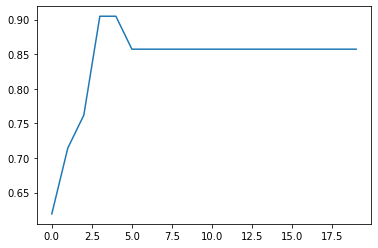

In [13]:
plt.plot(d)

## Checking using Cross validation

In [22]:
cv =[]
for i in range(1,41,2):
    
    model = KNeighborsClassifier(n_neighbors=i)
    cross_val = cross_val_score(model,X =x ,y=y,cv = 5)
    cv.append(cross_val.mean())
    print("For",i,"Negibours Cross Valadiation score is  : " ,cross_val.mean())

For 1 Negibours Cross Valadiation score is  :  0.7114285714285714
For 3 Negibours Cross Valadiation score is  :  0.7919047619047619
For 5 Negibours Cross Valadiation score is  :  0.730952380952381
For 7 Negibours Cross Valadiation score is  :  0.760952380952381
For 9 Negibours Cross Valadiation score is  :  0.7709523809523808
For 11 Negibours Cross Valadiation score is  :  0.7809523809523811
For 13 Negibours Cross Valadiation score is  :  0.7709523809523808
For 15 Negibours Cross Valadiation score is  :  0.7609523809523809
For 17 Negibours Cross Valadiation score is  :  0.7609523809523809
For 19 Negibours Cross Valadiation score is  :  0.7609523809523809
For 21 Negibours Cross Valadiation score is  :  0.7709523809523808
For 23 Negibours Cross Valadiation score is  :  0.7709523809523808
For 25 Negibours Cross Valadiation score is  :  0.7609523809523809
For 27 Negibours Cross Valadiation score is  :  0.780952380952381
For 29 Negibours Cross Valadiation score is  :  0.770952380952381
For 

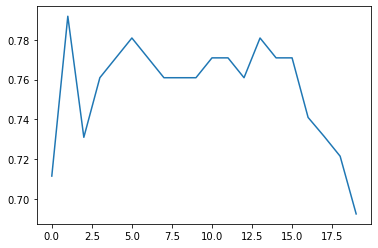

In [19]:
plt.plot(cv)

In [24]:
model = KNeighborsClassifier(n_neighbors=9)
x_train,x_test,y_train,t_test = train_test_split(x,y,random_state=12,test_size=0.20,stratify=y)
model.fit(x_train,y_train)
y_test_pred = model.predict(x_test)
print("Accurcy Score    :" ,accuracy_score(y_test_pred,y_test))

Accurcy Score    : 0.9047619047619048


## Conclusion : KNN model with 9 Neighbours is our Hero Model